In [2]:
import pandas as pd

In [ ]:
df_24 = pd.read_csv("./moomotion/data/CWB_2024.csv")
df_25 = pd.read_csv("./moomotion/data/CWB_2025.csv")

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.experiments import get_experiment_features

In [14]:
features = get_experiment_features(8)

from core.features import LabeledDatasetFeatures, SmaxtecFeatures


smaxtec_features = [
        LabeledDatasetFeatures.ANIMAL_ID.feature_name,
        LabeledDatasetFeatures.DATETIME.feature_name,
        LabeledDatasetFeatures.LABEL.feature_name,
        SmaxtecFeatures.ACTIVITY.feature_name,
        SmaxtecFeatures.CALVING_INDEX.feature_name,
        SmaxtecFeatures.TEMPERATURE.feature_name,
        SmaxtecFeatures.RUMINATING_INDEX.feature_name,
        SmaxtecFeatures.TEMPERATURE_NORMAL_INDEX.feature_name,
        SmaxtecFeatures.HEAT_INDEX.feature_name,
        SmaxtecFeatures.WATER_INTAKE.feature_name,
]
features_without_label = [f for f in smaxtec_features if f != "Stehen/Liegen"]

Using 20 PCA features (common numeric intersection).


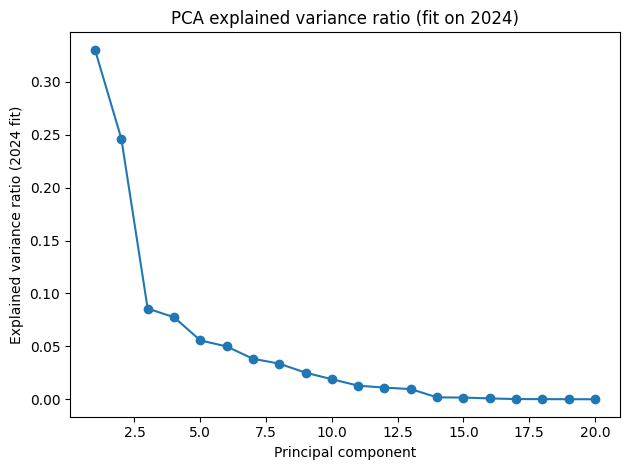

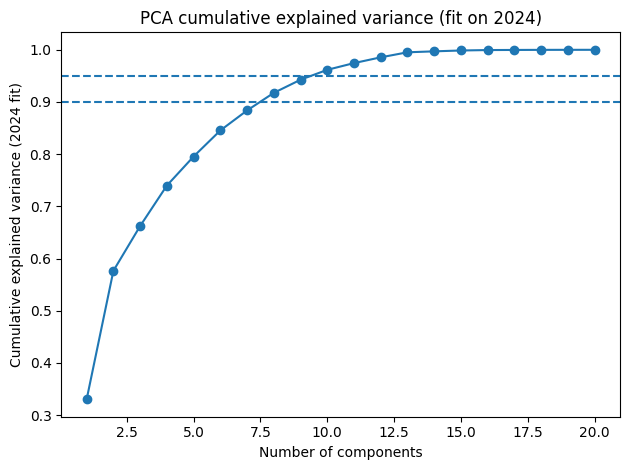

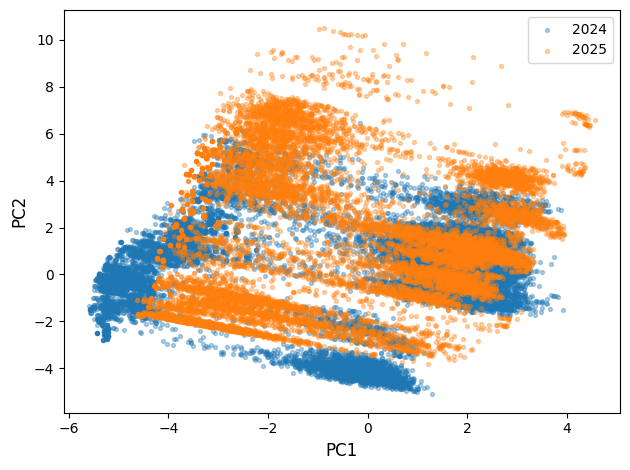

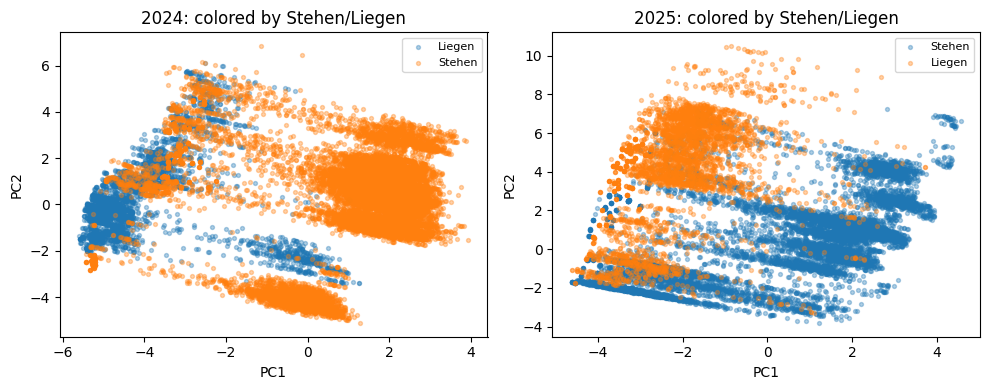

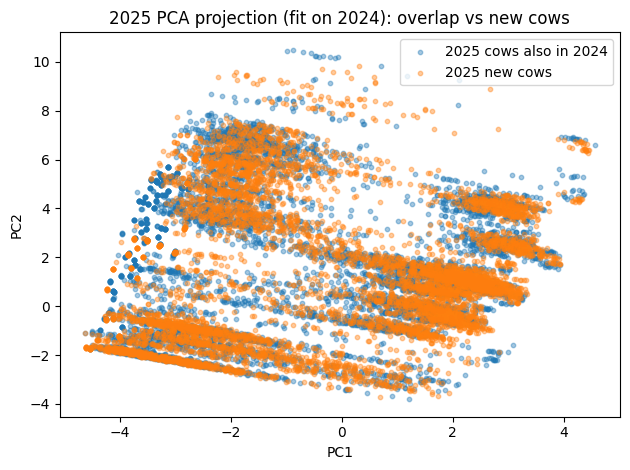


Top contributors to PC1:
             feature   loading  abs_loading
IMU_Tick_Count_120mG  0.364056     0.364056
IMU_Tick_Count_160mG  0.363130     0.363130
 IMU_Tick_Count_80mG  0.360408     0.360408
IMU_Tick_Count_200mG  0.358506     0.358506
IMU_Tick_Count_240mG  0.351403     0.351403
 IMU_Tick_Count_40mG  0.335603     0.335603
                 act  0.247340     0.247340
       GroundT_C_Avg  0.206246     0.206246
          AirT_C_Avg  0.206155     0.206155
            RelHumid -0.188875     0.188875
     WindSpd_m_s_Avg  0.184747     0.184747
       PotSlrRad_Avg -0.119453     0.119453
        Rad_SWin_Avg  0.055915     0.055915
           rum_index -0.042190     0.042190
   temp_normal_index  0.040516     0.040516

Top contributors to PC2:
             feature   loading  abs_loading
        Rad_SWin_Avg  0.413847     0.413847
          AirT_C_Avg  0.361948     0.361948
            RelHumid -0.360616     0.360616
       GroundT_C_Avg  0.355763     0.355763
     WindSpd_m_s_Avg  0.

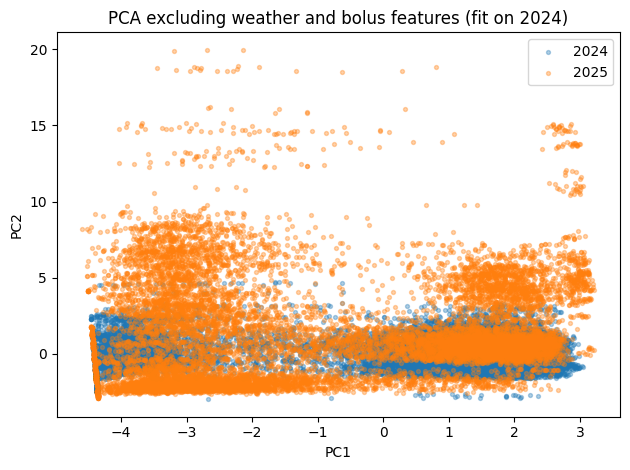


(Excluding weather and bolus) Top contributors to PC1:
             feature   loading  abs_loading
IMU_Tick_Count_160mG  0.415926     0.415926
IMU_Tick_Count_120mG  0.415843     0.415843
IMU_Tick_Count_200mG  0.411625     0.411625
 IMU_Tick_Count_80mG  0.411591     0.411591
IMU_Tick_Count_240mG  0.403761     0.403761
 IMU_Tick_Count_40mG  0.389576     0.389576
         Odometer_km -0.021100     0.021100


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -------------------------
# Config
# -------------------------
LABEL_COL = "Stehen/Liegen"
ID_COL = "animal_id"
TIME_COL = "datetime"

DROP_ALWAYS = {LABEL_COL, ID_COL, TIME_COL}

features = get_experiment_features(8)

# -------------------------
# Load data
# -------------------------
df_24 = pd.read_csv("./moomotion/data/CWB_2024.csv")
df_25 = pd.read_csv("./moomotion/data/CWB_2025.csv")

df_24["year"] = 2024
df_25["year"] = 2025


# Ensure we also remove ID/time/label
features_for_pca = [c for c in features if c not in DROP_ALWAYS]

# Keep only numeric features (PCA needs numeric)
def numeric_feature_list(df, cols):
    numeric_cols = []
    for c in cols:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            numeric_cols.append(c)
    return numeric_cols

features_for_pca_24 = numeric_feature_list(df_24, features_for_pca)
features_for_pca_25 = numeric_feature_list(df_25, features_for_pca)

# Intersect to ensure both years have identical feature columns
features_for_pca_common = sorted(list(set(features_for_pca_24).intersection(set(features_for_pca_25))))

if len(features_for_pca_common) == 0:
    raise ValueError("No common numeric PCA features found between df_24 and df_25.")

print(f"Using {len(features_for_pca_common)} PCA features (common numeric intersection).")

# -------------------------
# Clean data (NaNs/inf)
# -------------------------
def clean_X(df, feature_cols):
    X = df[feature_cols].copy()
    # Replace inf with NaN
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X24_raw = clean_X(df_24, features_for_pca_common)
X25_raw = clean_X(df_25, features_for_pca_common)

# impute with training (2024) medians
train_medians = X24_raw.median(numeric_only=True)
X24 = X24_raw.fillna(train_medians)
X25 = X25_raw.fillna(train_medians)  # use 2024 medians to avoid peeking into 2025

# -------------------------
# Fit scaler on 2024, transform both
# -------------------------
scaler = StandardScaler()
X24_scaled = scaler.fit_transform(X24.values)
X25_scaled = scaler.transform(X25.values)

# -------------------------
# Fit PCA on 2024, project both into same PCA space
# -------------------------
pca_full = PCA()  # all components
pca_full.fit(X24_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# Choose number of components for plots
N_VIS = 2
pca_vis = PCA(n_components=max(N_VIS, 3)) 
pca_vis.fit(X24_scaled)

Z24 = pca_vis.transform(X24_scaled)
Z25 = pca_vis.transform(X25_scaled)

# -------------------------
# Build a combined frame for plotting
# -------------------------
plot_cols = [f"PC{i+1}" for i in range(Z24.shape[1])]

df24_plot = pd.DataFrame(Z24, columns=plot_cols)
df25_plot = pd.DataFrame(Z25, columns=plot_cols)

# Add metadata for plotting
for dfi, src in [(df24_plot, df_24), (df25_plot, df_25)]:
    dfi["year"] = src["year"].values
    if ID_COL in src.columns:
        dfi[ID_COL] = src[ID_COL].values
    if LABEL_COL in src.columns:
        dfi[LABEL_COL] = src[LABEL_COL].values
    # optionally also keep datetime if you want to facet by time
    if TIME_COL in src.columns:
        dfi[TIME_COL] = src[TIME_COL].values

df_plot = pd.concat([df24_plot, df25_plot], ignore_index=True)

# -------------------------
# 1) Explained variance plots (from full PCA on 2024)
# -------------------------
plt.figure()
plt.plot(np.arange(1, len(explained) + 1), explained, marker="o")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio (2024 fit)")
plt.title("PCA explained variance ratio (fit on 2024)")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(np.arange(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (2024 fit)")
plt.title("PCA cumulative explained variance (fit on 2024)")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.tight_layout()
plt.show()

# -------------------------
# 2) PC1 vs PC2 scatter: color by YEAR
# -------------------------
plt.figure()
for yr in sorted(df_plot["year"].unique()):
    m = df_plot["year"] == yr
    plt.scatter(df_plot.loc[m, "PC1"], df_plot.loc[m, "PC2"], s=8, alpha=0.35, label=str(yr))
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
# plt.title("PCA projection (fit on 2024): colored by year")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------
# 3) PC1 vs PC2 scatter: color by LABEL, with years split into subplots
# -------------------------
if LABEL_COL in df_plot.columns and df_plot[LABEL_COL].notna().any():
    years = sorted(df_plot["year"].unique())
    plt.figure(figsize=(10, 4))

    for i, yr in enumerate(years, start=1):
        plt.subplot(1, len(years), i)
        d = df_plot[df_plot["year"] == yr].copy()

        # Handle label values robustly
        # If label is string ("Stehen"/"Liegen") it will work; if numeric (0/1) also works
        for lbl in d[LABEL_COL].dropna().unique():
            mm = d[LABEL_COL] == lbl
            plt.scatter(d.loc[mm, "PC1"], d.loc[mm, "PC2"], s=8, alpha=0.35, label=str(lbl))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"{yr}: colored by {LABEL_COL}")
        plt.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print(f"Label column '{LABEL_COL}' missing or all NaN; skipping label-colored plots.")

# -------------------------
# 4) Optional: 2025 only, distinguish cows seen in 2024 vs new cows
# -------------------------
if ID_COL in df_24.columns and ID_COL in df_25.columns:
    cows_24 = set(df_24[ID_COL].dropna().unique())
    cows_25 = set(df_25[ID_COL].dropna().unique())
    overlap = cows_24.intersection(cows_25)

    df_plot["in_2024"] = False
    m25 = df_plot["year"] == 2025
    if m25.any() and ID_COL in df_plot.columns:
        df_plot.loc[m25, "in_2024"] = df_plot.loc[m25, ID_COL].isin(overlap)

    plt.figure()
    d25 = df_plot[df_plot["year"] == 2025]
    for flag in [True, False]:
        mm = d25["in_2024"] == flag
        plt.scatter(d25.loc[mm, "PC1"], d25.loc[mm, "PC2"], s=10, alpha=0.4,
                    label=("2025 cows also in 2024" if flag else "2025 new cows"))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("2025 PCA projection (fit on 2024): overlap vs new cows")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("animal_id not found in both datasets; skipping overlap/new cows plot.")

# -------------------------
# 5) PCA loadings: which features drive PC1/PC2
# -------------------------
# Loadings are components_ scaled by sqrt(eigenvalues); a common, readable proxy is just components_
# We'll show the largest absolute contributors for PC1 and PC2.
components = pca_vis.components_  # shape: (n_components, n_features)
feat = np.array(features_for_pca_common)

def top_loadings(pc_index, k=12):
    v = components[pc_index]
    idx = np.argsort(np.abs(v))[::-1][:k]
    return pd.DataFrame({
        "feature": feat[idx],
        "loading": v[idx],
        "abs_loading": np.abs(v[idx]),
    }).sort_values("abs_loading", ascending=False)

print("\nTop contributors to PC1:")
print(top_loadings(0, k=15).to_string(index=False))

print("\nTop contributors to PC2:")
print(top_loadings(1, k=15).to_string(index=False))

# -------------------------
# 6) Optional: quantify centroid shift in PCA space
# -------------------------
mu24 = df24_plot[["PC1", "PC2"]].mean().values
mu25 = df25_plot[["PC1", "PC2"]].mean().values
centroid_dist = np.linalg.norm(mu25 - mu24)

print(f"\nCentroid distance between 2024 and 2025 in (PC1, PC2): {centroid_dist:.4f}")

# -------------------------
# 7) Optional: repeat PCA excluding weather features to see if shift is weather-driven
# -------------------------
weather_like = {
    "AirT_C_Avg", "GroundT_C_Avg", "VWC_C_Avg", "RelHumid", "Rad_SWin_Avg",
    "WindSpd_m_s_Avg", "Rain_mm_Tot", "PotSlrRad_Avg", "temp", "water_intake", 
    "rum_index", "temp_normal_index", "calving_index", "heat_index", "act"
}

features_no_weather = [c for c in features_for_pca_common if c not in weather_like]
if len(features_no_weather) >= 2:
    X24_nw_raw = clean_X(df_24, features_no_weather).replace([np.inf, -np.inf], np.nan)
    X25_nw_raw = clean_X(df_25, features_no_weather).replace([np.inf, -np.inf], np.nan)
    med_nw = X24_nw_raw.median(numeric_only=True)
    X24_nw = X24_nw_raw.fillna(med_nw)
    X25_nw = X25_nw_raw.fillna(med_nw)

    scaler_nw = StandardScaler()
    X24_nw_s = scaler_nw.fit_transform(X24_nw.values)
    X25_nw_s = scaler_nw.transform(X25_nw.values)

    pca_nw = PCA(n_components=3)
    pca_nw.fit(X24_nw_s)
    Z24_nw = pca_nw.transform(X24_nw_s)
    Z25_nw = pca_nw.transform(X25_nw_s)

    plt.figure()
    plt.scatter(Z24_nw[:, 0], Z24_nw[:, 1], s=8, alpha=0.35, label="2024")
    plt.scatter(Z25_nw[:, 0], Z25_nw[:, 1], s=8, alpha=0.35, label="2025")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA excluding weather and bolus features (fit on 2024)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n(Excluding weather and bolus) Top contributors to PC1:")
    feat_nw = np.array(features_no_weather)
    comps_nw = pca_nw.components_
    v = comps_nw[0]
    idx = np.argsort(np.abs(v))[::-1][:15]
    print(pd.DataFrame({"feature": feat_nw[idx], "loading": v[idx], "abs_loading": np.abs(v[idx])})
          .sort_values("abs_loading", ascending=False).to_string(index=False))
else:
    print("Not enough non-weather features found to run weather-excluded PCA.")

/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/Users/luka/Library/Caches/pypoetry/virtualenvs/moomotion-FNnKyfLY-py3.12/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


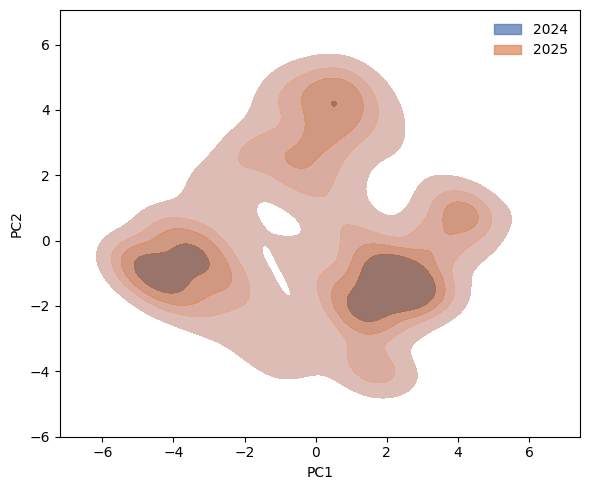

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(6, 5))

colors = ["#4C72B0", "#DD8452"]
years = sorted(df_plot["year"].unique())

for yr, color in zip(years, colors):
    subset = df_plot[df_plot["year"] == yr]

    sns.kdeplot(
        x=subset["PC1"],
        y=subset["PC2"],
        fill=True,
        alpha=0.7,
        levels=5,
        linewidths=1,
        color=color,
        ax=ax
    )

# 🔥 manual legend
handles = [
    Patch(facecolor=color, edgecolor=color, label=str(yr), alpha=0.7)
    for yr, color in zip(years, colors)
]

ax.legend(handles=handles, frameon=False)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

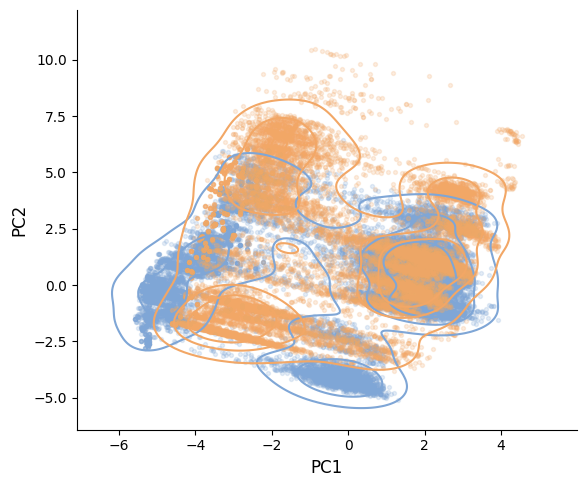

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))

colors = {2024: "#7FA6D6", 2025: "#F2A766"}

for yr in sorted(df_plot["year"].unique()):
    subset = df_plot[df_plot["year"] == yr]

    # scatter (light)
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=8,
        alpha=0.2,
        color=colors[yr],
    )

    # contour on top
    sns.kdeplot(
        x=subset["PC1"],
        y=subset["PC2"],
        levels=4,
        color=colors[yr],
        linewidths=1.5,
        ax=ax
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

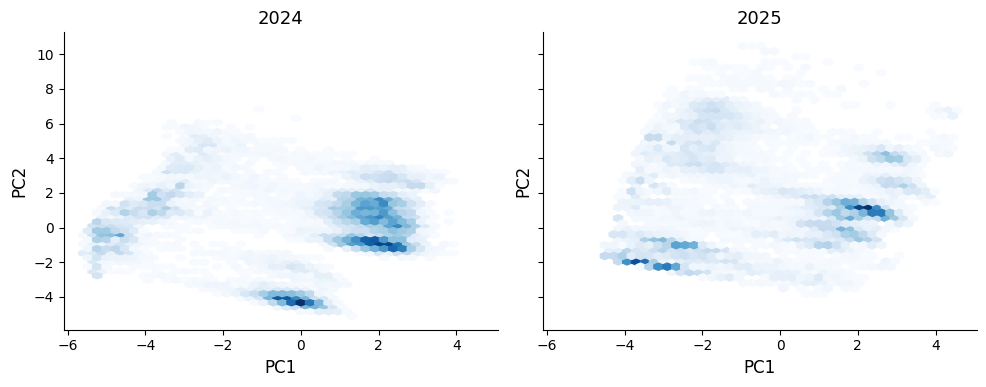

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, yr in zip(axes, sorted(df_plot["year"].unique())):
    subset = df_plot[df_plot["year"] == yr]

    hb = ax.hexbin(
        subset["PC1"],
        subset["PC2"],
        gridsize=40,
        cmap="Blues",
        mincnt=1
    )

    ax.set_title(str(yr))
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

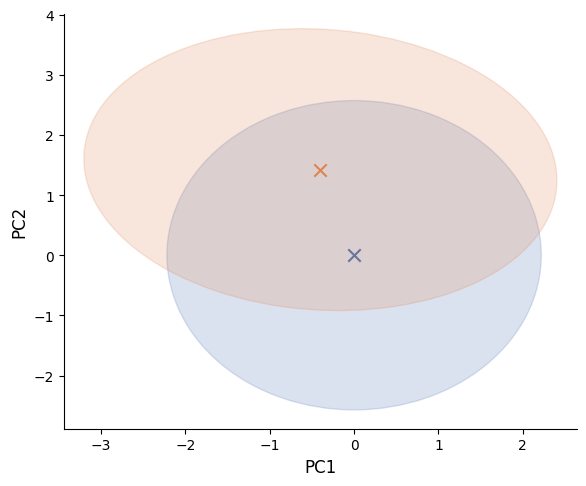

In [19]:
import matplotlib.patches as patches
import numpy as np

def plot_ellipse(ax, x, y, color):
    cov = np.cov(x, y)
    mean = [np.mean(x), np.mean(y)]

    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*eigvecs[:, 1][::-1]))

    width, height = 2 * np.sqrt(eigvals)

    ellipse = patches.Ellipse(
        mean, width, height, angle=angle,
        edgecolor=color, facecolor=color, alpha=0.2
    )
    ax.add_patch(ellipse)
    ax.scatter(*mean, color=color, marker="x", s=80)


fig, ax = plt.subplots(figsize=(6, 5))

colors = {2024: "#4C72B0", 2025: "#DD8452"}

for yr in sorted(df_plot["year"].unique()):
    subset = df_plot[df_plot["year"] == yr]

    plot_ellipse(
        ax,
        subset["PC1"],
        subset["PC2"],
        colors[yr]
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

Using 8 features for domain classifier.
Class distribution: [17561 13949]
Fold 1: AUC=0.6880, BalAcc=0.6191, n_test=6302
Fold 2: AUC=0.6841, BalAcc=0.6082, n_test=6301
Fold 3: AUC=0.7192, BalAcc=0.6375, n_test=6302
Fold 4: AUC=0.6719, BalAcc=0.6229, n_test=6302
Fold 5: AUC=0.7082, BalAcc=0.6297, n_test=6303

Domain classifier results (Logistic Regression, GroupKFold by cow):
Mean ROC-AUC: 0.6943 ± 0.0171
Mean Balanced Accuracy: 0.6235 ± 0.0099

Full-data fit (visualization only):
ROC-AUC: 0.7066
Balanced Accuracy: 0.6388
Confusion Matrix:
 [[14218  3343]
 [ 7422  6527]]


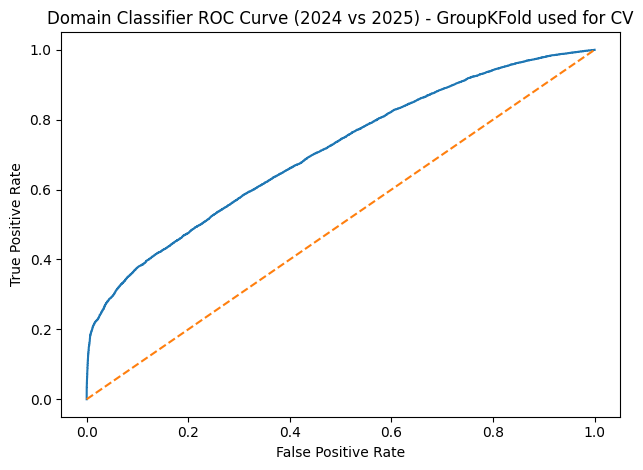

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, confusion_matrix, roc_curve

LABEL_COL = "Stehen/Liegen"
ID_COL = "animal_id"
TIME_COL = "datetime"

DROP_ALWAYS = {LABEL_COL, TIME_COL}  # we will use animal_id as groups, so don't drop it until after groups extraction

# -------------------------
# Build common feature set (same as before)
# -------------------------

#########
# CHANGE FEATURE SET HERE
# [1] ONLY COLLAR
# [3] COLLAR + WEATHER
# [4] COLLAR + BOLUS
# [8] ALL SENSORS 
###########
features = get_experiment_features(1)
features_for_domain = [c for c in features if c not in DROP_ALWAYS]

def numeric_feature_list(df, cols):
    return [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

f24 = numeric_feature_list(df_24, features_for_domain)
f25 = numeric_feature_list(df_25, features_for_domain)
common_features = sorted(list(set(f24).intersection(set(f25))))

print(f"Using {len(common_features)} features for domain classifier.")

def clean_X(df, feature_cols):
    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    return X

X24 = clean_X(df_24, common_features)
X25 = clean_X(df_25, common_features)

# Impute using 2024 medians (no peeking into 2025)
train_medians = X24.median(numeric_only=True)
X24 = X24.fillna(train_medians)
X25 = X25.fillna(train_medians)

# Domain labels
y = np.concatenate([
    np.zeros(len(X24), dtype=int),  # 0=2024
    np.ones(len(X25), dtype=int)    # 1=2025
])

# Groups: animal_id
if ID_COL not in df_24.columns or ID_COL not in df_25.columns:
    raise ValueError("animal_id not found in both df_24 and df_25, cannot run GroupKFold.")

g24 = df_24[ID_COL].astype(str).values
g25 = df_25[ID_COL].astype(str).values

# Important: make groups unique across years so the same numeric ID in 2024/2025 isn't treated as same group by accident
# If your animal_id is truly global and consistent across years, this is still safe.
groups = np.concatenate([
    np.char.add("2024_", g24),
    np.char.add("2025_", g25),
])

# Combine X
X = pd.concat([X24, X25], ignore_index=True)

print("Class distribution:", np.bincount(y))

# -------------------------
# GroupKFold CV
# -------------------------
gkf = GroupKFold(n_splits=5)

auc_scores = []
bal_acc_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_s, y_train)

    y_proba = clf.predict_proba(X_test_s)[:, 1]
    y_pred = clf.predict(X_test_s)

    auc = roc_auc_score(y_test, y_proba)
    bal = balanced_accuracy_score(y_test, y_pred)

    auc_scores.append(auc)
    bal_acc_scores.append(bal)

    print(f"Fold {fold}: AUC={auc:.4f}, BalAcc={bal:.4f}, n_test={len(test_idx)}")

print("\nDomain classifier results (Logistic Regression, GroupKFold by cow):")
print(f"Mean ROC-AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Mean Balanced Accuracy: {np.mean(bal_acc_scores):.4f} ± {np.std(bal_acc_scores):.4f}")

# -------------------------
# Fit once on full data for ROC curve + confusion matrix (visualization only)
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_scaled, y)

y_proba = clf.predict_proba(X_scaled)[:, 1]
y_pred = clf.predict(X_scaled)

print("\nFull-data fit (visualization only):")
print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y, y_pred))

fpr, tpr, _ = roc_curve(y, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Domain Classifier ROC Curve (2024 vs 2025) - GroupKFold used for CV")
plt.tight_layout()
plt.show()